In [3]:
def add(a, b):
    return a + b
def fancy_func(a, b, c, d):
    e = add(a, b)
    f = add(c, d)
    g = add(e, f)
    return g
print(fancy_func(1, 2, 3, 4))

10


In [5]:
def add_():
    return '''
def add(a, b):
    return a + b
'''
def fancy_func_():
    return '''
def fancy_func(a, b, c, d):
    e = add(a, b)
    f = add(c, d)
    g = add(e, f)
    return g
'''

def evoke_():
    return add_() + fancy_func_() + 'print(fancy_func(1, 2, 3, 4))'
prog = evoke_()
print(prog)
y = compile(prog, '', 'exec')
exec(y)


def add(a, b):
    return a + b

def fancy_func(a, b, c, d):
    e = add(a, b)
    f = add(c, d)
    g = add(e, f)
    return g
print(fancy_func(1, 2, 3, 4))
10


In [7]:
import torch
from torch import nn
from d2l import torch as d2l

def get_net():
    net = nn.Sequential(
        nn.Linear(512, 256), nn.ReLU(),
        nn.Linear(256, 128), nn.ReLU(),
        nn.Linear(128, 2)
    )
    return net

x = torch.randn(size=(1, 512))
net = get_net()
net(x)

tensor([[0.0210, 0.0313]], grad_fn=<AddmmBackward0>)

In [9]:
net = torch.jit.script(net)
net(x)

tensor([[0.0210, 0.0313]], grad_fn=<AddmmBackward0>)

In [11]:
class Benchmark:
    def __init__(self, description='Done'):
        self.description = description

    def __enter__(self):
        self.timer = d2l.Timer()
        return self

    def __exit__(self, *args):
        print(f'{self.description}: {self.timer.stop():.4f} sec')

In [15]:
net = get_net()
with Benchmark('no torchscript'):
    for i in range(1000): net(x)

net = torch.jit.script(net)
with Benchmark('torchscript'):
    for i in range(1000): net(x)

no torchscript: 0.1677 sec
torchscript: 0.2937 sec


In [21]:
net.save('my_mlp')
# !ls-lh my_mlp*

In [23]:
import os
import subprocess
import numpy
import torch
from torch import nn
from d2l import torch as d2l

In [25]:
device = d2l.try_gpu()
a = torch.randn(size=(1000, 1000), device=device)
b = torch.mm(a, a)

with d2l.Benchmark('numpy'):
    for _ in range(10):
        a = numpy.random.normal(size=(1000, 1000))
        b = numpy.dot(a, a)

with d2l.Benchmark('torch'):
    for _ in range(10):
        a = torch.randn(size=(1000, 1000), device=device)
        b = torch.mm(a, a)

numpy: 0.4842 sec
torch: 0.0020 sec


In [27]:
with d2l.Benchmark():
    for _ in range(10):
        a = torch.randn(size=(1000, 1000), device=device)
        b = torch.mm(a, a)
    torch.cuda.synchronize(device)

Done: 0.0041 sec


In [29]:
x = torch.ones((1, 2), device=device)
y = torch.ones((1, 2), device=device)
z = x * y + 2
z

tensor([[3., 3.]], device='cuda:0')

In [31]:
import torch
from d2l import torch as d2l

In [35]:
# devices = d2l.try_all_gpus()
# def run(x):
#     return [x.mm(x) for _ in range(50)]

# x_gpu1 = torch.rand(size=(4000, 4000), device=devices[0])
# x_gpu2 = torch.rand(size=(4000, 4000), device=devices[1])

# only one GPU QAQ

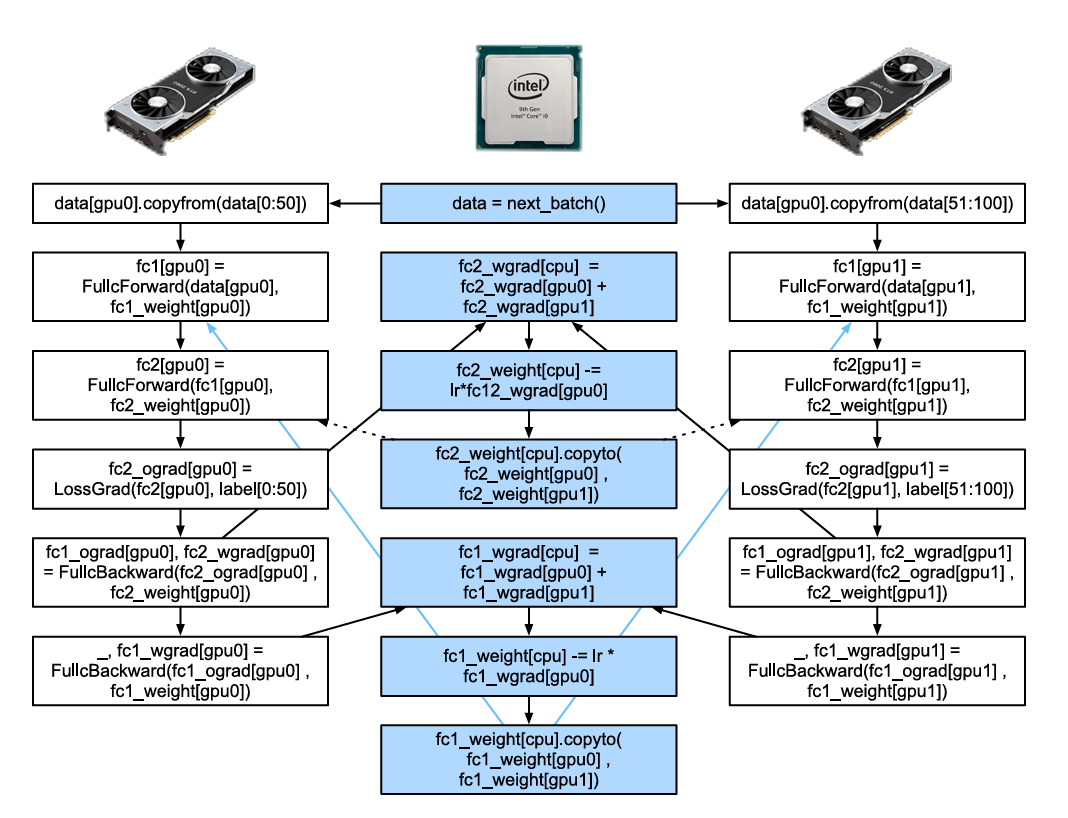